# Notebook 01 — Individual Baseline vs. Breed Average

> *A dog can remain normal for its breed while becoming abnormal for itself.*

**Barkley Canine Cognition Lab · Research Demonstrator · Synthetic Data Only**

---

## Purpose

This notebook demonstrates the central methodological thesis of the Barkley framework:

**Current breed-level normative models are blind to individual cognitive drift.**

We show this using synthetic data: a population of 100 simulated dogs, each with an individually-established baseline, some of whom experience simulated behavioral drift. We then compare what a breed-level model "sees" vs. what an individual baseline model detects.

---

## What You'll Learn

1. How individual behavioral baselines differ from breed population averages
2. Why a dog can appear "normal" in a breed comparison while drifting from its own baseline
3. How to construct an individual baseline from longitudinal behavioral data
4. The quantitative gap between breed-level and individual-level anomaly detection

---

> **Disclaimer:** All data is synthetic. No clinical claims are made. This is a research and methodological demonstration only.


## 0. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Barkley palette
COLORS = {
    "primary":    "#1A1A2E",
    "accent":     "#7B61FF",
    "signal":     "#FF4F6D",
    "stable":     "#00C9A7",
    "neutral":    "#B0B3C1",
    "bg":         "#F8F9FC",
    "breed_band": "#D0D3E8",
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   COLORS['bg'],
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load dataset
df = pd.read_csv('../data/synthetic_doggraph_sample.csv', parse_dates=['date'])
print(f"Dataset loaded: {df.shape[0]:,} records, {df['dog_id'].nunique()} dogs")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing data rate: {df['data_missing'].mean()*100:.1f}%")


Dataset loaded: 36,500 records, 100 dogs
Date range: 2025-01-01 to 2025-12-31
Missing data rate: 7.2%


## 1. The Problem: Breed-Level Normative Models

Before demonstrating individual baselines, let's understand what breed-level models actually compute — and why they fail at individual detection.

A breed-level model asks: **"Is this value within the population distribution for this breed?"**

Let's visualize what that looks like for sleep duration across our synthetic population.


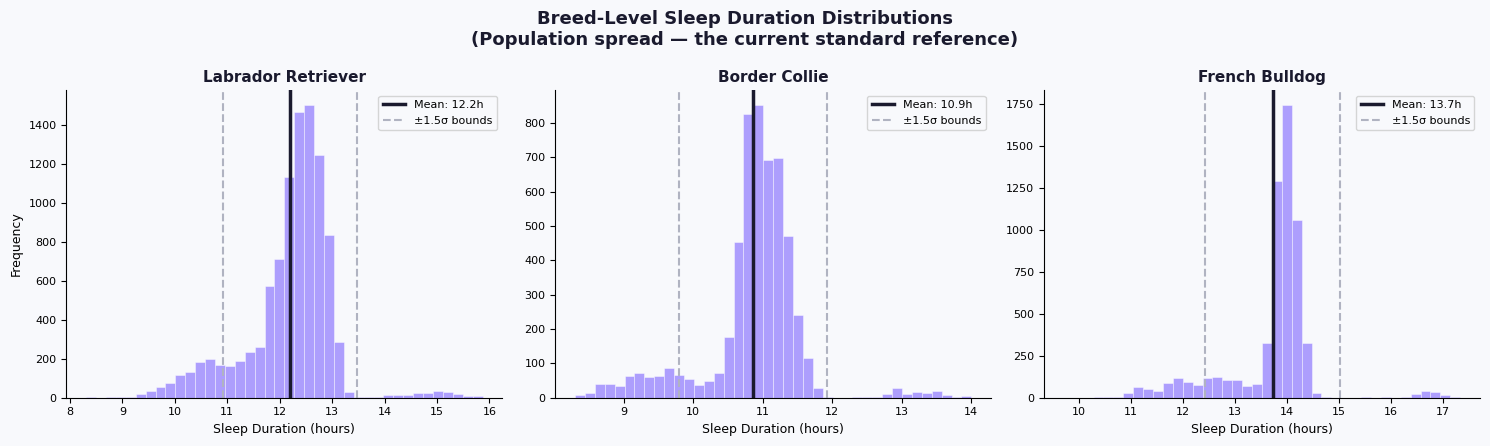

Observation: Wide population spread within each breed.
A dog sleeping 11h looks unremarkable in a Labrador population.
But if that dog always slept 14h... it's a different story.


In [2]:
# ── Breed population distributions ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Breed-Level Sleep Duration Distributions\n(Population spread — the current standard reference)",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

breeds_to_show = ['Labrador Retriever', 'Border Collie', 'French Bulldog']

for i, breed in enumerate(breeds_to_show):
    ax = axes[i]
    ax.set_facecolor(COLORS['bg'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    breed_data = df[(df['breed'] == breed) & (~df['data_missing'])]['sleep_hours'].dropna()
    
    ax.hist(breed_data, bins=40, color=COLORS['accent'], alpha=0.6, edgecolor='white', linewidth=0.5)
    
    mu, sigma = breed_data.mean(), breed_data.std()
    ax.axvline(mu, color=COLORS['primary'], linewidth=2.5, label=f'Mean: {mu:.1f}h')
    ax.axvline(mu - 1.5*sigma, color=COLORS['neutral'], linewidth=1.5, linestyle='--', label='±1.5σ bounds')
    ax.axvline(mu + 1.5*sigma, color=COLORS['neutral'], linewidth=1.5, linestyle='--')
    
    ax.set_title(f'{breed}', fontsize=11, fontweight='bold', color=COLORS['primary'])
    ax.set_xlabel('Sleep Duration (hours)', fontsize=9)
    ax.set_ylabel('Frequency' if i == 0 else '', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../figures/breed_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Observation: Wide population spread within each breed.")
print("A dog sleeping 11h looks unremarkable in a Labrador population.")
print("But if that dog always slept 14h... it's a different story.")


## 2. Individual Baselines: Every Dog Is Its Own Reference

The Barkley approach establishes an **individual baseline** for each dog from its own behavioral history.

The baseline is computed from the dog's stable period (months 1–5), before any behavioral drift begins.

Key distinction:
- **Breed model**: compares today's value to the breed population
- **Individual model**: compares today's value to *this dog's own history*


In [3]:
# ── Individual baselines across the cohort ────────────────────────────────

# Compute per-dog baselines from stable period (months 1-5)
stable_period = df[(df['month'] <= 5) & (~df['data_missing'])]
individual_baselines = stable_period.groupby(['dog_id', 'breed'])['sleep_hours'].agg(
    baseline_mean='mean',
    baseline_std='std',
    n_obs='count'
).reset_index()
individual_baselines = individual_baselines[individual_baselines['n_obs'] >= 20]  # min 20 obs

print(f"Individual baselines computed for {len(individual_baselines)} dogs")
print(f"\nBaseline statistics (sleep_hours):")
print(individual_baselines.groupby('breed')['baseline_mean'].describe().round(2))


Individual baselines computed for 100 dogs

Baseline statistics (sleep_hours):
                    count   mean   std    min    25%    50%    75%    max
breed                                                                    
Beagle               25.0  11.81  0.27  11.31  11.62  11.78  12.02  12.32
Border Collie        16.0  10.89  0.23  10.55  10.72  10.90  11.05  11.27
French Bulldog       18.0  13.81  0.15  13.56  13.71  13.83  13.91  14.17
Golden Retriever     12.0  12.88  0.16  12.59  12.80  12.87  12.97  13.22
Labrador Retriever   29.0  12.27  0.35  11.68  12.07  12.22  12.53  12.86


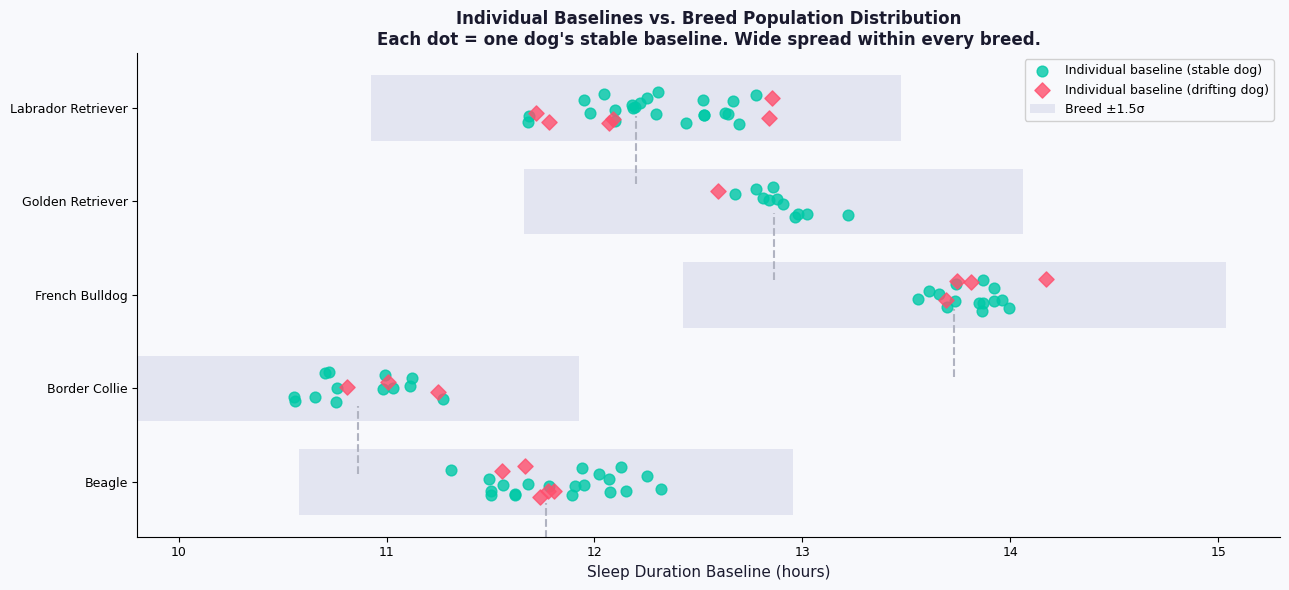

Key insight: Individual baselines span a wide range within each breed.
A 'high sleeper' Labrador and a 'low sleeper' Labrador are fundamentally different individuals.
Breed-level norms treat them identically.


In [4]:
# ── The key visualization: breed mean vs individual baselines ─────────────

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor(COLORS['bg'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

breeds = individual_baselines['breed'].unique()
breed_positions = {b: i*4 for i, b in enumerate(sorted(breeds))}

for breed, grp in individual_baselines.groupby('breed'):
    pos = breed_positions[breed]
    
    # Breed population band
    breed_obs = df[(df['breed'] == breed) & (~df['data_missing'])]['sleep_hours'].dropna()
    breed_mean, breed_std = breed_obs.mean(), breed_obs.std()
    
    ax.barh(pos, breed_std * 3, left=breed_mean - 1.5*breed_std, height=2.8,
            color=COLORS['breed_band'], alpha=0.5, label='Breed ±1.5σ' if breed == sorted(breeds)[0] else '')
    ax.axvline(breed_mean, ymin=(pos-1.4)/(len(breeds)*4), ymax=(pos+1.4)/(len(breeds)*4),
               color=COLORS['neutral'], linewidth=1.5, linestyle='--')
    
    # Individual dots
    jitter = np.random.uniform(-0.7, 0.7, len(grp))
    has_drift = grp['dog_id'].isin(df[df['has_drift']]['dog_id'].unique())
    
    ax.scatter(grp.loc[~has_drift, 'baseline_mean'],
               pos + jitter[~has_drift.values],
               color=COLORS['stable'], s=60, alpha=0.8, zorder=3,
               label='Individual baseline (stable dog)' if breed == sorted(breeds)[0] else '')
    ax.scatter(grp.loc[has_drift, 'baseline_mean'],
               pos + jitter[has_drift.values],
               color=COLORS['signal'], s=60, alpha=0.8, marker='D', zorder=4,
               label='Individual baseline (drifting dog)' if breed == sorted(breeds)[0] else '')

ax.set_yticks([breed_positions[b] for b in sorted(breeds)])
ax.set_yticklabels(sorted(breeds), fontsize=10)
ax.set_xlabel('Sleep Duration Baseline (hours)', fontsize=11, color=COLORS['primary'])
ax.set_title('Individual Baselines vs. Breed Population Distribution\n'
             'Each dot = one dog\'s stable baseline. Wide spread within every breed.',
             fontsize=12, fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9, framealpha=0.9)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('../figures/individual_baselines_by_breed.png', dpi=120, bbox_inches='tight')
plt.show()

print("Key insight: Individual baselines span a wide range within each breed.")
print("A 'high sleeper' Labrador and a 'low sleeper' Labrador are fundamentally different individuals.")
print("Breed-level norms treat them identically.")


## 3. The Detection Gap: Who Sees the Drift?

Now the critical demonstration.

We take dogs with simulated behavioral drift, and ask two questions:
1. **Breed model**: does this dog's current behavior fall outside breed normal range?
2. **Individual model**: does this dog's current behavior fall outside its own established baseline?

The difference in detection rates is the core argument for individual longitudinal modeling.


In [5]:
# ── Detection comparison: breed vs individual ──────────────────────────────

drift_dogs = df[df['has_drift']]['dog_id'].unique()

results = []

for dog_id in drift_dogs:
    dog = df[df['dog_id'] == dog_id].copy()
    breed = dog['breed'].iloc[0]
    
    # Establish individual baseline (months 1–5)
    stable = dog[(dog['month'] <= 5) & (~dog['data_missing'])]['sleep_hours'].dropna()
    if len(stable) < 15:
        continue
    ind_mean, ind_std = stable.mean(), stable.std()
    
    # Breed population stats
    breed_obs = df[(df['breed'] == breed) & (~df['data_missing'])]['sleep_hours'].dropna()
    breed_mean, breed_std = breed_obs.mean(), breed_obs.std()
    
    # Drift period (months 8–12)
    drift = dog[(dog['month'] >= 8) & (~dog['data_missing'])]['sleep_hours'].dropna()
    if len(drift) < 10:
        continue
    drift_mean = drift.mean()
    
    # Detection
    breed_z     = abs(drift_mean - breed_mean) / breed_std
    individual_z = abs(drift_mean - ind_mean)  / max(ind_std, 0.1)
    
    breed_detected      = breed_z     > 1.5   # outside ±1.5σ of breed
    individual_detected  = individual_z > 1.5  # outside ±1.5σ of individual baseline
    
    results.append({
        'dog_id': dog_id,
        'breed': breed,
        'ind_baseline': ind_mean,
        'breed_mean': breed_mean,
        'drift_mean': drift_mean,
        'breed_z': breed_z,
        'individual_z': individual_z,
        'breed_detected': breed_detected,
        'individual_detected': individual_detected,
        'missed_by_breed': individual_detected and not breed_detected,
    })

results_df = pd.DataFrame(results)
print("=== DETECTION RESULTS ===")
print(f"Dogs analyzed: {len(results_df)}")
print(f"Breed model detected:      {results_df['breed_detected'].sum()} / {len(results_df)} ({results_df['breed_detected'].mean()*100:.0f}%)")
print(f"Individual model detected: {results_df['individual_detected'].sum()} / {len(results_df)} ({results_df['individual_detected'].mean()*100:.0f}%)")
print(f"\nDrift detected by individual model but MISSED by breed model:")
print(f"  {results_df['missed_by_breed'].sum()} dogs ({results_df['missed_by_breed'].mean()*100:.0f}%)")
print(f"\nThese are dogs that look 'normal' by breed standards,")
print(f"but are significantly drifting from their own baseline.")


=== DETECTION RESULTS ===
Dogs analyzed: 19
Breed model detected:      1 / 19 (5%)
Individual model detected: 3 / 19 (16%)

Drift detected by individual model but MISSED by breed model:
  2 dogs (11%)

These are dogs that look 'normal' by breed standards,
but are significantly drifting from their own baseline.


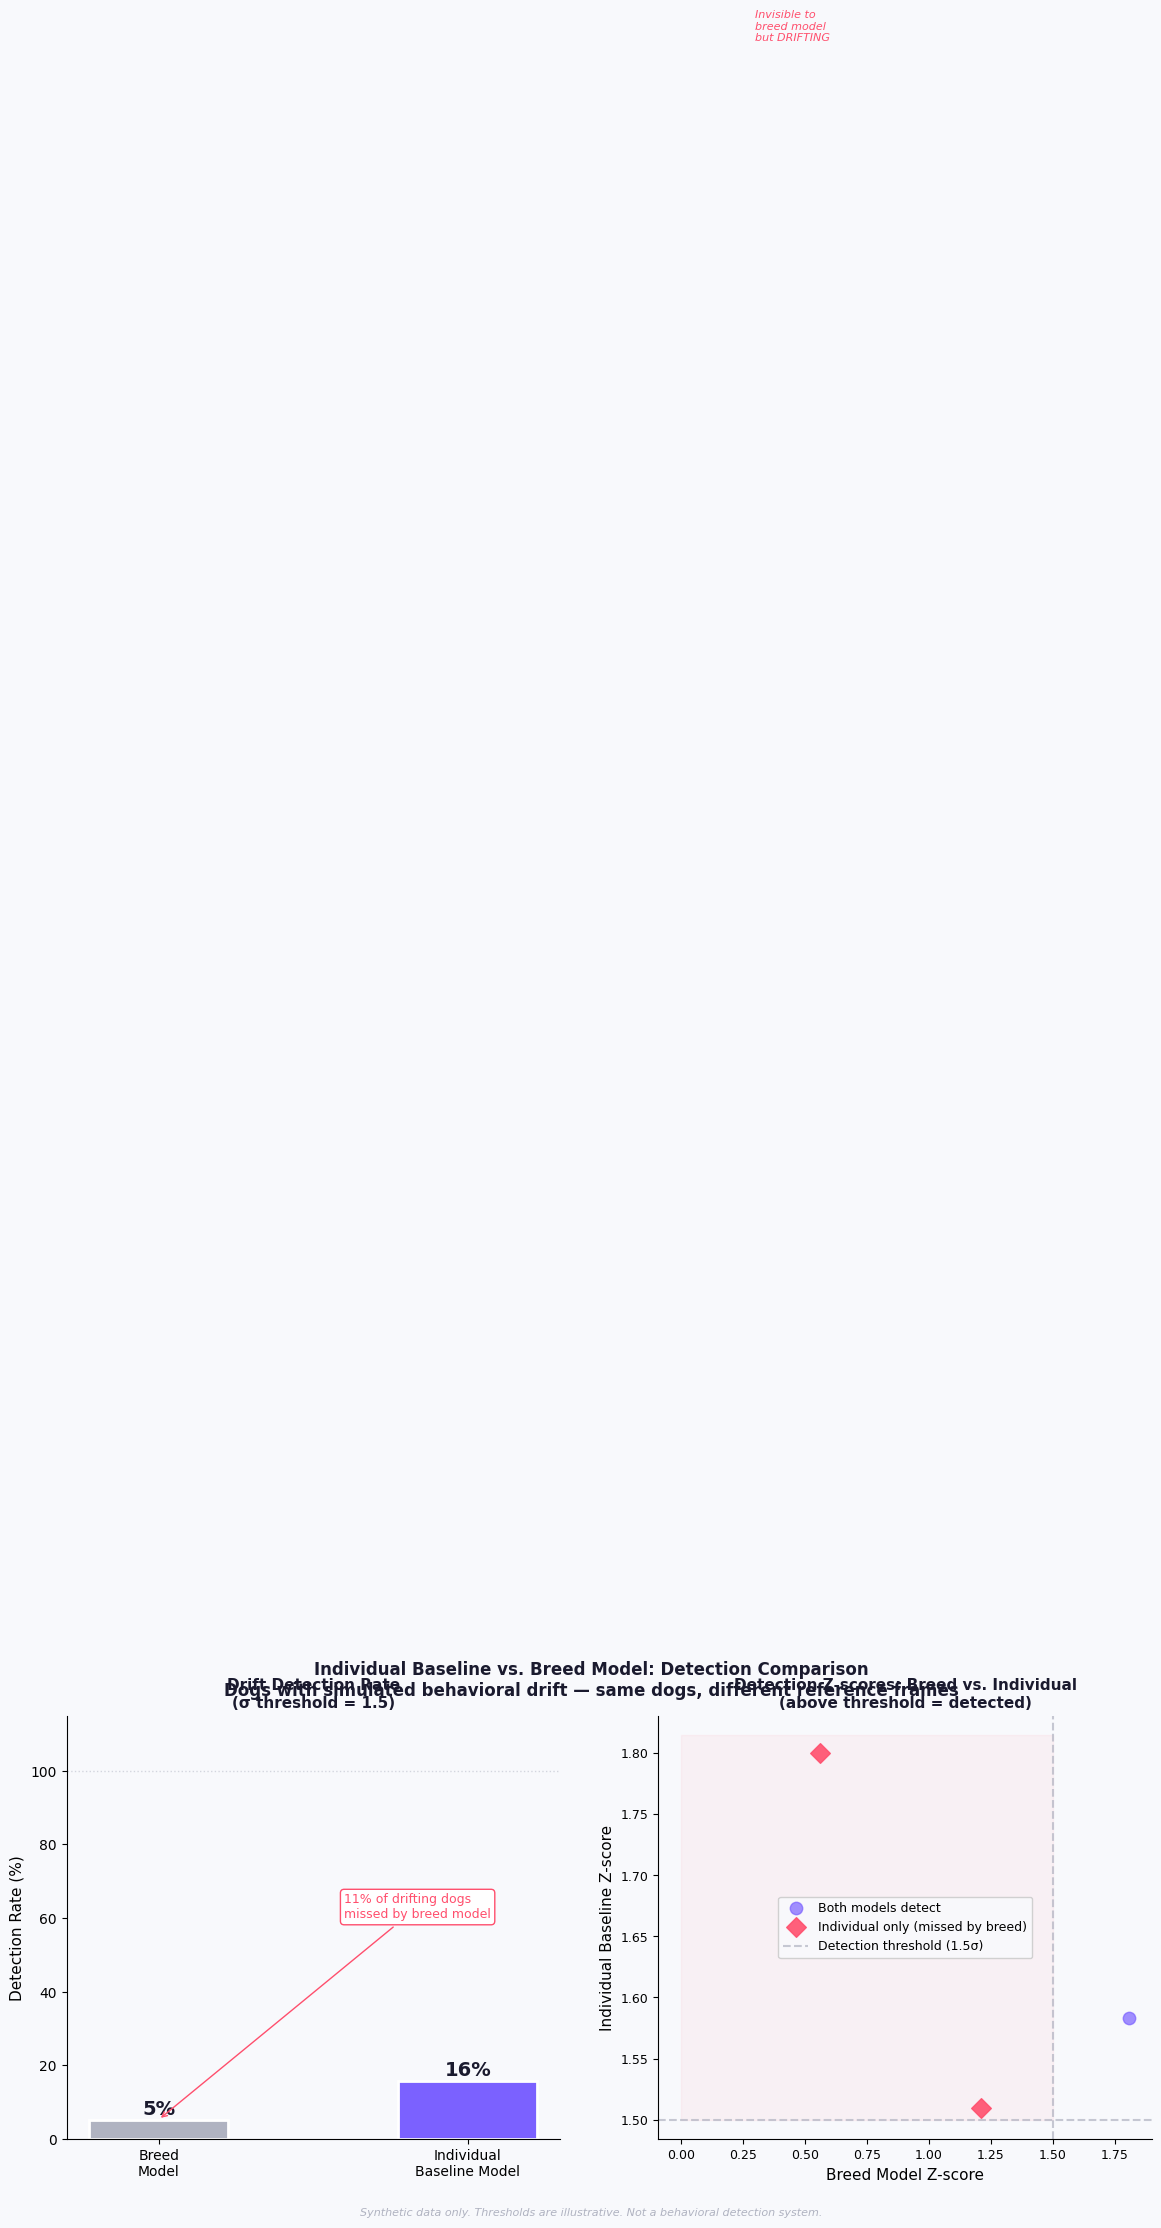

In [6]:
# ── Visualize the detection gap ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Individual Baseline vs. Breed Model: Detection Comparison\n'
             'Dogs with simulated behavioral drift — same dogs, different reference frames',
             fontsize=12, fontweight='bold', color=COLORS['primary'])

# Left: detection rates
ax = axes[0]
ax.set_facecolor(COLORS['bg'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

categories = ['Breed\nModel', 'Individual\nBaseline Model']
detected   = [results_df['breed_detected'].mean()*100, results_df['individual_detected'].mean()*100]
bar_colors = [COLORS['neutral'], COLORS['accent']]

bars = ax.bar(categories, detected, color=bar_colors, width=0.45, edgecolor='white', linewidth=2)
for bar, val in zip(bars, detected):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', fontsize=14, fontweight='bold',
            color=COLORS['primary'])

ax.axhline(100, color=COLORS['neutral'], linewidth=1, linestyle=':', alpha=0.5)
ax.set_ylim(0, 115)
ax.set_ylabel('Detection Rate (%)', fontsize=11)
ax.set_title('Drift Detection Rate\n(σ threshold = 1.5)', fontsize=11, fontweight='bold', color=COLORS['primary'])
ax.tick_params(labelsize=10)

missed_pct = results_df['missed_by_breed'].mean()*100
ax.annotate(f'{missed_pct:.0f}% of drifting dogs\nmissed by breed model',
            xy=(0, detected[0]), xytext=(0.6, 60),
            fontsize=9, color=COLORS['signal'],
            arrowprops=dict(arrowstyle='->', color=COLORS['signal']),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['signal']))

# Right: z-scores scatter
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

missed    = results_df[results_df['missed_by_breed']]
detected_both = results_df[results_df['breed_detected'] & results_df['individual_detected']]
only_breed = results_df[results_df['breed_detected'] & ~results_df['individual_detected']]

ax2.scatter(detected_both['breed_z'], detected_both['individual_z'],
            color=COLORS['accent'], s=80, alpha=0.7, label='Both models detect', zorder=3)
ax2.scatter(missed['breed_z'], missed['individual_z'],
            color=COLORS['signal'], s=100, alpha=0.9, marker='D', label='Individual only (missed by breed)', zorder=4)

ax2.axvline(1.5, color=COLORS['neutral'], linewidth=1.5, linestyle='--', alpha=0.7, label='Detection threshold (1.5σ)')
ax2.axhline(1.5, color=COLORS['neutral'], linewidth=1.5, linestyle='--', alpha=0.7)

ax2.set_xlabel('Breed Model Z-score', fontsize=11)
ax2.set_ylabel('Individual Baseline Z-score', fontsize=11)
ax2.set_title('Detection Z-scores: Breed vs. Individual\n(above threshold = detected)',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax2.legend(fontsize=9, framealpha=0.9)
ax2.tick_params(labelsize=9)

# Annotate the "invisible to breed" zone
ax2.fill_betweenx([1.5, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 1.5 else 4],
                   0, 1.5, color=COLORS['signal'], alpha=0.05)
ax2.text(0.3, 3.2, 'Invisible to\nbreed model\nbut DRIFTING',
         fontsize=8, color=COLORS['signal'], style='italic')

fig.text(0.5, -0.03, 'Synthetic data only. Thresholds are illustrative. Not a behavioral detection system.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('../figures/detection_gap_breed_vs_individual.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. One Dog, Closely

Let's zoom into a single dog to make the argument concrete.

We'll trace one Labrador Retriever through its full year, comparing what a breed model sees vs. what an individual baseline model sees.


Case study: DOG_0075
Breed: Beagle | Age group: adult
Individual baseline (M1-M5): 11.66h ± 0.57h
Breed population mean:       11.77h ± 0.79h
Note: Individual baseline (11.7h) vs breed mean (11.8h) = -0.1h difference


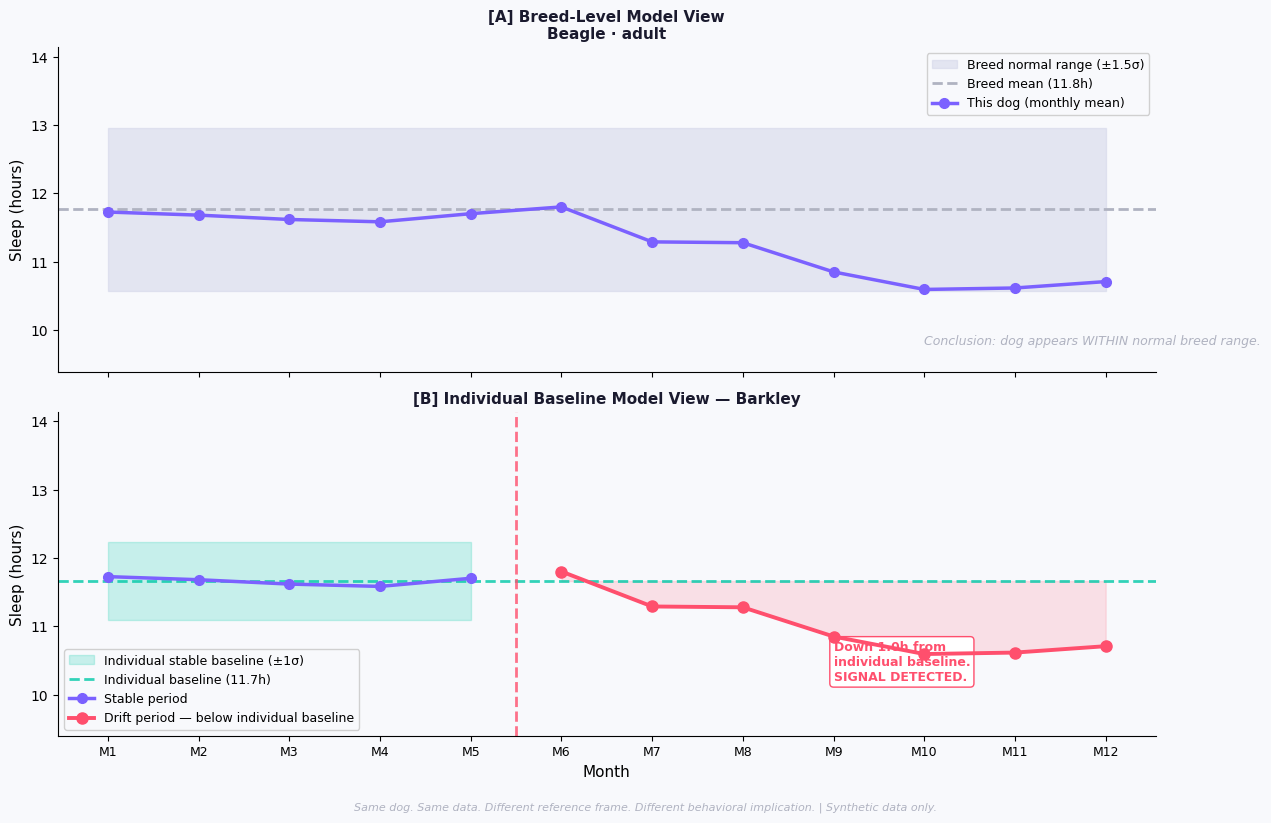

In [7]:
# ── Single dog case study ──────────────────────────────────────────────────

# Pick a dog that's missed by breed model but caught by individual
if len(missed) > 0:
    case_dog_id = missed.iloc[0]['dog_id']
else:
    case_dog_id = results_df.iloc[0]['dog_id']

case_dog = df[df['dog_id'] == case_dog_id].copy()
case_breed = case_dog['breed'].iloc[0]
case_age = case_dog['age_group'].iloc[0]
case_obs = case_dog[~case_dog['data_missing']].copy().sort_values('date')

# Individual baseline
stable_obs = case_obs[case_obs['month'] <= 5]['sleep_hours'].dropna()
ind_mean   = stable_obs.mean()
ind_std    = stable_obs.std()

# Breed stats
breed_obs  = df[(df['breed'] == case_breed) & (~df['data_missing'])]['sleep_hours'].dropna()
breed_mean = breed_obs.mean()
breed_std  = breed_obs.std()

print(f"Case study: {case_dog_id}")
print(f"Breed: {case_breed} | Age group: {case_age}")
print(f"Individual baseline (M1-M5): {ind_mean:.2f}h ± {ind_std:.2f}h")
print(f"Breed population mean:       {breed_mean:.2f}h ± {breed_std:.2f}h")
print(f"Note: Individual baseline ({ind_mean:.1f}h) vs breed mean ({breed_mean:.1f}h) = {ind_mean-breed_mean:+.1f}h difference")

# Rolling monthly means
monthly_means = case_obs.groupby('month')['sleep_hours'].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])
months_x = monthly_means.index.tolist()

# ── Top: breed model view ──
ax1.set_facecolor(COLORS['bg'])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.fill_between(months_x,
                  breed_mean - 1.5*breed_std, breed_mean + 1.5*breed_std,
                  color=COLORS['breed_band'], alpha=0.5, label=f'Breed normal range (±1.5σ)')
ax1.axhline(breed_mean, color=COLORS['neutral'], linewidth=2, linestyle='--', label=f'Breed mean ({breed_mean:.1f}h)')
ax1.plot(months_x, monthly_means.values, color=COLORS['accent'], linewidth=2.5,
          marker='o', markersize=7, label='This dog (monthly mean)', zorder=3)

ax1.set_ylabel('Sleep (hours)', fontsize=11)
ax1.set_title(f'[A] Breed-Level Model View\n{case_breed} · {case_age.replace("_", " ")}',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax1.legend(fontsize=9, framealpha=0.9)
ax1.set_ylim(breed_mean - 3*breed_std, breed_mean + 3*breed_std)
ax1.text(10, breed_mean - 2.5*breed_std, 'Conclusion: dog appears WITHIN normal breed range.',
         fontsize=9, color=COLORS['neutral'], style='italic')

# ── Bottom: individual baseline view ──
ax2.set_facecolor(COLORS['bg'])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.fill_between(range(1, 6),
                  ind_mean - ind_std, ind_mean + ind_std,
                  color=COLORS['stable'], alpha=0.2, label='Individual stable baseline (±1σ)')
ax2.axhline(ind_mean, color=COLORS['stable'], linewidth=2, linestyle='--',
             alpha=0.8, label=f'Individual baseline ({ind_mean:.1f}h)')

stable_months = [m for m in months_x if m <= 5]
drift_months  = [m for m in months_x if m > 5]

ax2.plot(stable_months, [monthly_means[m] for m in stable_months],
          color=COLORS['accent'], linewidth=2.5, marker='o', markersize=7,
          label='Stable period', zorder=3)
ax2.plot(drift_months, [monthly_means[m] for m in drift_months],
          color=COLORS['signal'], linewidth=2.8, marker='o', markersize=8,
          label='Drift period — below individual baseline', zorder=4)

if drift_months:
    ax2.fill_between(drift_months,
                      ind_mean,
                      [monthly_means[m] for m in drift_months],
                      color=COLORS['signal'], alpha=0.15)

ax2.axvline(5.5, color=COLORS['signal'], linewidth=2, linestyle='--', alpha=0.8)
ax2.set_ylabel('Sleep (hours)', fontsize=11)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_title('[B] Individual Baseline Model View — Barkley',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax2.set_xticks(months_x)
ax2.set_xticklabels([f'M{m}' for m in months_x], fontsize=9)
ax2.legend(fontsize=9, framealpha=0.9, loc='lower left')
ax2.set_ylim(breed_mean - 3*breed_std, breed_mean + 3*breed_std)

drift_val = monthly_means.iloc[-1] if len(monthly_means) > 0 else ind_mean
ax2.text(9, drift_val - 0.5,
         f'Down {ind_mean - drift_val:.1f}h from\nindividual baseline.\nSIGNAL DETECTED.',
         fontsize=9, color=COLORS['signal'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['signal']))

fig.text(0.5, -0.02, 'Same dog. Same data. Different reference frame. Different behavioral implication. | Synthetic data only.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')
plt.tight_layout()
plt.savefig('../figures/single_dog_case_study.png', dpi=120, bbox_inches='tight')
plt.show()


## Summary

This notebook demonstrated the central Barkley methodological argument with synthetic data:

| | Breed-Level Model | Individual Baseline Model |
|---|---|---|
| Reference point | Population mean (breed) | Dog's own history |
| Sensitive to | Population-level outliers | Individual-level drift |
| Early drift detection | Limited | Improved |
| Requires longitudinal data | No | Yes |
| Erases individual cognitive identity | Yes | No |

### The One-Line Argument

> *A dog can remain statistically normal for its breed while becoming abnormal for itself.*

Breed-level models cannot see this. Individual longitudinal models can.

---

### Next Steps

- **Notebook 02**: How to detect drift statistically — temporal methods and thresholds
- **Notebook 03**: The Missing Data Paradox — what absence of data tells us

---

> **Research note**: All analysis here uses synthetic data. The detection rates shown are illustrative of the methodological principle, not claims about detection performance. Real validation requires prospective longitudinal studies with veterinarian-confirmed endpoints.
